### Logistic Regression Model:
##### Linear regression gives you a continuous output, but logistic regression provides a constant output.
##### An example of the continuous output is house price and stock price.
##### Example of the discrete output is predicting whether a patient has cancer or not.
##### Linear regression is estimated using Ordinary Least Squares (OLS).
##### Logistic regression is estimated using Maximum Likelihood Estimation (MLE) approach.

The MLE is a "likelihood" maximization method, while OLS is a distance-minimizing approximation method.
Maximizing the likelihood function determines the parameters that are most likely to produce the observed data.
From a statistical point of view, MLE sets the mean and variance as parameters in determining the specific parametric values for a given model.
This set of parameters can be used for predicting the data needed in a normal distribution.

Ordinary Least squares estimates are computed by fitting a regression line on given data points that has the minimum sum of the squared deviations (least square error). Both are used to estimate the parameters of a linear regression model.
MLE assumes a joint probability mass function, while OLS doesn't require any stochastic assumptions for minimizing distance.

The SIGMOID function, also called logistic function gives an ‘S’ shaped curve that can take any real-valued number and map it into a value between 0 and 1.
If the curve goes to positive infinity, y predicted will become 1, and if the curve goes to negative infinity, y predicted will become 0.
If the output of the sigmoid function is more than 0.5, we can classify the outcome as 1 or YES, and if it is less than 0.5, we can classify it as 0 or NO.

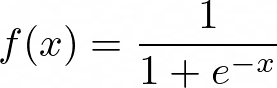

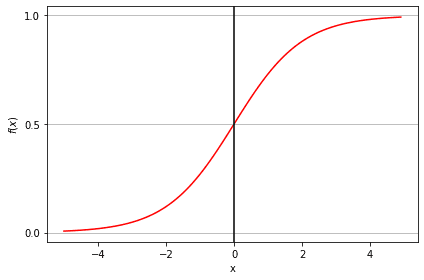

#### Loading Data:
Let's build the diabetes prediction model.
The goal is to predict diabetes using the Logistic Regression Classifier.
Let's first load the required Pima Indian Diabetes dataset using the pandas' read_csv() method.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
# load dataset
pima = pd.read_csv("diabetes.csv")

In [3]:
# displaying the first five items:
pima.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
pima.shape

(768, 9)

#### Selecting Features:
Let's divide the given columns into two types of variables dependent(or target variable) and independent variable(or feature variables).

In [5]:
#split dataset in features and target variable
feature_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'Insulin','BMI',
                'DiabetesPedigreeFunction','Age']
X = pima[feature_cols] # Features
y = pima.Outcome # Target variable

#### Splitting Data:
75% data will be used for model training and 25% for model testing.

Why Use random_state?
Machine learning algorithms often involve randomness, such as:

Shuffling data before splitting into training and testing sets.

Initializing model parameters (e.g., in stochastic optimization methods).

Handling tie-breaking in decision boundaries (especially in some classifiers).

By setting random_state, you ensure that every time you run the model, it produces the same results—helping in debugging, comparison, and reproducibility.

Any integer (e.g., 42, 0, 1, etc.) ensures the same results every time.

In [6]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)

In [7]:
X_train.shape

(576, 7)

In [8]:
X_test.shape

(192, 7)

#### Model Development and Prediction:

In [9]:
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
logreg = LogisticRegression(random_state=16)

# fit the model with data
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

#### Model Evaluation using Confusion Matrix:
The fundamental of a confusion matrix is the number of correct and incorrect predictions summed up class-wise.

A 2×2 confusion matrix is used to evaluate the performance of a binary classification model. Each cell in the matrix represents a count of predicted vs. actual values.

In [10]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[116,   9],
       [ 26,  41]])

- The confusion matrix is in the form of the array object.
- The dimension of this matrix is 2*2 because this model is binary classification.
- There are two classes 0 and 1.
- In the output, 116 and 41 are actual predictions, and 26 and 9 are incorrect predictions.

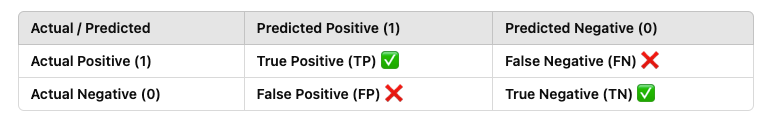

Explanation of Each Cell:

True Positive (TP) – Model correctly predicts positive when the actual value is positive.

False Negative (FN) – Model incorrectly predicts negative when the actual value is positive (missed detection).

False Positive (FP) – Model incorrectly predicts positive when the actual value is negative (false alarm).

True Negative (TN) – Model correctly predicts negative when the actual value is negative.

Example Use Case:

For a medical test for a disease:

TP → The test correctly identifies a sick patient as sick.

FN → The test misses a sick patient (bad outcome).

FP → The test falsely classifies a healthy person as sick (leads to unnecessary worry/treatment).

TN → The test correctly identifies a healthy person as healthy.

#### Visualizing Confusion Matrix using Heatmap:

Text(0.5, 427.9555555555555, 'Predicted label')

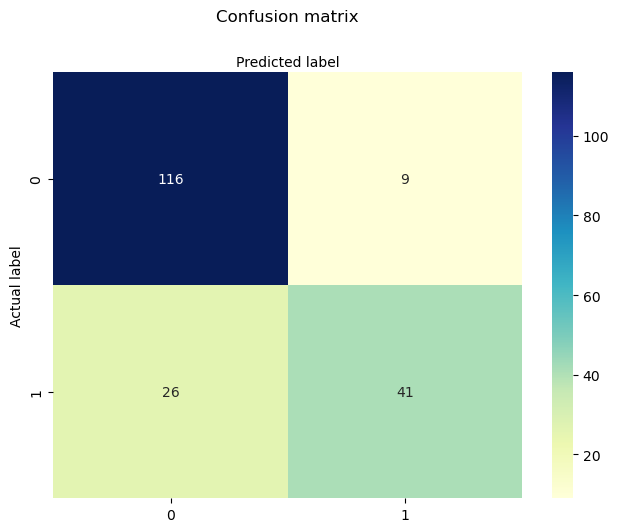

In [11]:
# import required modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

### Confusion Matrix Evaluation Metrics:
Key Metrics Derived from the Confusion Matrix:

Precision: (How many predicted positives are actually positive?) What do you notice for the denominator? The denominator is actually the Total Predicted Positive!
You can see that Precision talks about how precise/accurate your model is out of those predicted positive, how many of them are actual positive.
In our prediction case, when your Logistic Regression model predicted patients are going to suffer from diabetes, that patients have 82% of the time.
Precision is a good measure to determine, when the costs of False Positive is high. For instance, email spam detection. In email spam detection, a false positive means that an email that is non-spam (actual negative) has been identified as spam (predicted spam). The email user might lose important emails if the precision is not high for the spam detection model.

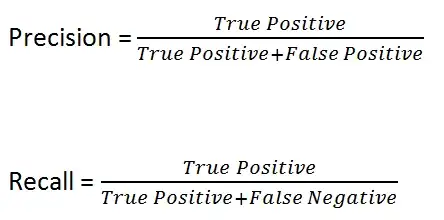

Recall (Sensitivity): (How many actual positives were correctly identified?) What do you notice for the denominator? The denominator is actually the Total Actual Positive! Recall shall be the model metric we use to select our best model when there is a high cost associated with False Negative.
For instance, in fraud detection, if a fraudulent transaction (Actual Positive) is predicted as non-fraudulent (Predicted Negative), the consequence can be very bad for the bank.
Similarly, in sick patient detection, if a sick patient (Actual Positive) goes through the test and predicted as not sick (Predicted Negative), the cost associated with False Negative will be extremely high if the sickness is contagious.
In our case, if there are patients who have diabetes in the test set and your Logistic Regression model can identify it 61% of the time.

Specificity or True Negative Rate: It tells us what proportion of the negative class got correctly classified. For example, it would mean determining the proportion of healthy people who were correctly identified by the model.

TNR = TN / (TN + FP)

F1 score: It is needed when you want to seek a balance between Precision and Recall. It is the harmonic mean of Precision and Recall and gives a better measure of the incorrectly classified cases than the Accuracy Metric. 

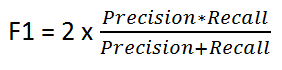

Accuracy: It observes correctly classified items both positive and negative.

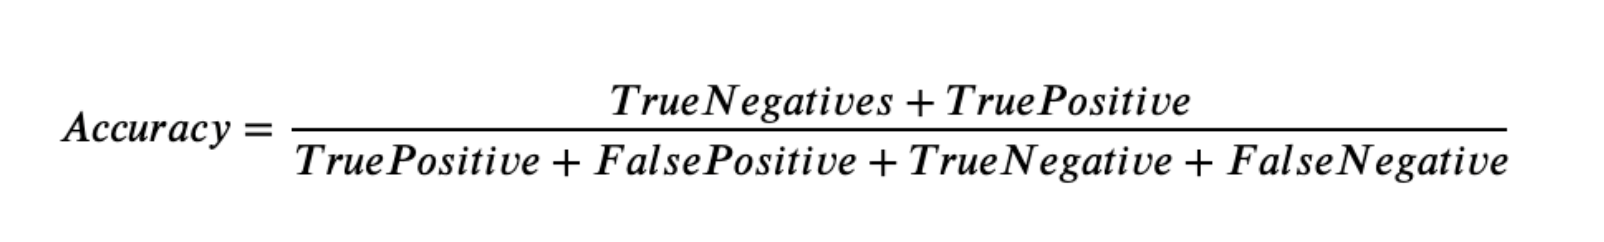

So what is the difference between F1 Score and Accuracy?

- Accuracy is used when the True Positives and True negatives are more important while F1-score is used when the False Negatives and False Positives are crucial.
- Accuracy can be used when the class distribution is similar while F1-score is a better metric when there are imbalanced classes.
- In most real-life classification problems, imbalanced class distribution exists and thus F1-score is a better metric to evaluate our models on.

In [12]:
from sklearn.metrics import classification_report
target_names = ['without diabetes', 'with diabetes']
print(classification_report(y_test, y_pred, target_names=target_names))

                  precision    recall  f1-score   support

without diabetes       0.82      0.93      0.87       125
   with diabetes       0.82      0.61      0.70        67

        accuracy                           0.82       192
       macro avg       0.82      0.77      0.78       192
    weighted avg       0.82      0.82      0.81       192



- Precision = 41/(41+9) = 41/50 = 82/100 = 0.82
- Recall = 41/(41/26) = 41/67 = 0.61
- F1 = 2*(0.82*0.61)/(0.82+0.61) = 0.70
- Accuracy = (116+41)/(116+9+26+41) = 0.82

### ROC Curve:
Receiver Operating Characteristic(ROC) curve is a plot of the true positive rate against the false positive rate. The ROC curve is plotted with TPR against the FPR where TPR is on the y-axis and FPR is on the x-axis.

True Positive Rate (TPR) is a synonym for recall or sensitivity as we described previously.

False Positive Rate (FPR) is defined as:

FPR = FP / (FP + TN)


### AUC: Area Under the ROC Curve
AUC stands for "Area under the ROC Curve." That is, AUC measures the entire two-dimensional area underneath the entire ROC curve (think integral calculus) from (0,0) to (1,1).
In Machine Learning, performance measurement is an essential task. So when it comes to a classification problem, we can count on an AUC.
It tells how much the model is capable of distinguishing between classes. Higher the AUC, the better the model is at predicting 0 classes as 0 and 1 classes as 1. By analogy, the Higher the AUC, the better the model is at distinguishing between patients with the disease and no disease.

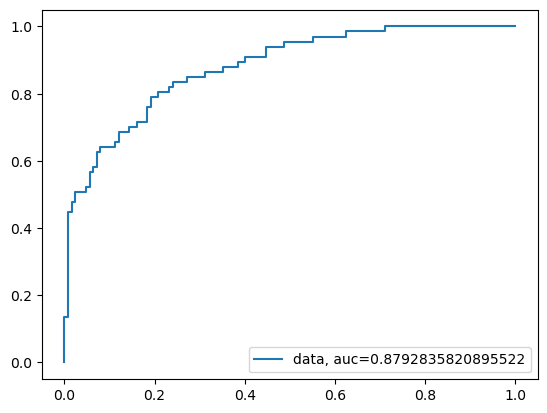

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score
y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr, tpr, _ = roc_curve(y_test,  y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data, auc="+str(auc))
plt.legend(loc=4)
plt.show()